In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import medfilt


In [ ]:
## noise-based blink detection

def diff(series):
	"""
	Python implementation of matlab's diff function
	"""
	return series[1:] - series[:-1]

def smooth(x, window_len, method='flat'):
	"""
	Better implementation of MATLAB's smooth function (moving average filter)
	Supports: flat (moving average), hanning, hamming, bartlett, blackman

	It handles edges by symmetric reflection to avoid edge artifacts.
	"""
	x = np.array(x, dtype=float)

	if window_len < 3:
		return x

	# must be singular
	if window_len % 2 == 0:
		window_len += 1

	window_len = int(window_len)
		
	if method == 'flat':
		w = np.ones(window_len)
	elif method == 'hanning':
		w = np.hanning(window_len)
	elif method == 'hamming':
		w = np.hamming(window_len)
	elif method == 'bartlett':
		w = np.bartlett(window_len)
	elif method == 'blackman':
		w = np.blackman(window_len)
	else:
		raise ValueError("Invalid method")

	x_padded = np.pad(x, (window_len//2, window_len//2), mode='reflect')

	y = np.convolve(w / w.sum(), x_padded, mode='valid')
	return y

def based_noise_blinks_detection(pupil_size, sampling_freq):
	"""
	Function to find blinks and return blink onset and offset indices
	Adapted from: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

	Input:
		pupil_size          : [numpy array/list] of pupil size data for left/right eye
		sampling_freq       : [float] sampling frequency of eye tracking hardware (default = 1000 Hz)
		concat              : [boolean] concatenate close blinks/missing trials or not. See R. Hershman et. al. for more information
		concat_gap_interval : [float] interval between successive missing samples/blinks to concatenate
	Output:
		blinks              : [dictionary] {"blink_onset", "blink_offset"} containing numpy array/list of blink onset and offset indices
	"""
	sampling_interval = 1000 / sampling_freq # In our case, the sampling frequency is 1200 Hz
	concat_gap_interval = 100

	blink_onset = []
	blink_offset = []
	blinks = {"blink_onset": blink_onset, "blink_offset": blink_offset}

	pupil_size = np.asarray(pupil_size) # Cannot transfer nan to 0, so in the next line of code, we have to identify the nan instead of 0
	missing_data = np.array(np.isnan(pupil_size), dtype="float32")
	difference = diff(missing_data)

	blink_onset = np.where(difference == 1)[0]
	blink_offset = np.where(difference == -1)[0] + 1

	length_blinks = len(blink_offset) + len(blink_onset)


	# Edge Case 1: there are no blinks
	if (length_blinks == 0):
		return blinks


	# Edge Case 2: the data starts with a blink. In this case, blink onset will be defined as the first missing value.
	"""
		Two possible situations may cause this:
			i.  starts with a blink but does not end with a blink ---> len(blink_onset) < len(blink_offset)
			ii. starts with a blink and ends with a blink		  ---> len(blink_onset) == len(blink_offset) and (blink_onset[0] == blink_offset[0])
	"""
	if ((len(blink_onset) < len(blink_offset)) or ((len(blink_onset) == len(blink_offset)) and (blink_onset[0] > blink_offset[0]))) and np.isnan(pupil_size[0]):
		blink_onset = np.hstack((0, blink_onset))


	# Edge Case 3: the data ends with a blink. In this case, blink offset will be defined as the last missing sample
	"""
		Two possible situations may cause this:
			i.  ends with a blink but does not start with a blink ---> len(blink_offset) < len(blink_onset)
			ii. ends with a blink and starts with a blink		  ---> Already handled "start with blink" in Edge case 2 so it reduces to i (previous case)
	"""
	if (len(blink_offset) < len(blink_onset)) and np.isnan(pupil_size[-1]):
		blink_offset = np.hstack((blink_offset, len(pupil_size) - 1))

	# Smoothing the data in order to increase the difference between the measurement noise and the eyelid signal.
	ms_4_smoothing = 30
	samples2smooth = int(ms_4_smoothing / sampling_interval)
	smooth_pupil_size = np.array(smooth(pupil_size, samples2smooth), dtype='float32')

	smooth_pupil_size[np.where(smooth_pupil_size == 0)[0]] = float('nan')
	smooth_pupil_size_diff = diff(smooth_pupil_size)

	"""
	Finding values <=0 and >=0 in order to find monotonically increasing and decreasing sections of smoothened pupil data

			Eg. a =     [2, 1, 2, 8, 7, 6, 5, 4, 4, 0, 0, 0, 0, 0, 3, 3, 3, 8, 9, 10, 2, 3, 10]
	                              ----------------  S           E  =================
			diff(a)=   [-1  1  6 -1 -1 -1 -1  0 -4  0  0  0  0  3  0  0  5  1  1  -8  1  7]

	monotonically_dec = [T  F  F  T  T  T  T  T  T  T  T  T  T  F  T  T  F  F  F   T  F  F]   (T=True, F=False)
	monotonically_dec = [F  T  T  F  F  F  F  T  F  T  T  T  T  T  T  T  T  T  T   F  T  T]

	---> The monotonically decreasing sequence before the blink is underlined with -- and the monotonically increasing sequence after the blink with ==
	---> S : denotes the initially detected onset of blink
	---> E : denotes the initially detected offset of blink

	>> Looking at diff(a), all values in the montonically decreasing sequence should be <= 0 and those included in the monotonically increasing sequence >= 0
	>> Hence, by moving left from the initially detected onset while T(True) values are encountered in monotonically_dec we can update the onset to the start of monotonically_dec seq
	>> By moving right from the initially detected offset while T(True) values are encountered in monotonically_inc we can update the offset to the end of monotonically_inc seq + 1
	"""
	monotonically_dec = smooth_pupil_size_diff <= 0
	monotonically_inc = smooth_pupil_size_diff >= 0

	# Finding correct blink onsets and offsets using monotonically increasing and decreasing arrays
	for i in range(len(blink_onset)):
		# Edge Case 2: If data starts with blink we do not update it and let starting blink index be 0
		if blink_onset[i] != 0:
			j = blink_onset[i] - 1
			while j > 0 and monotonically_dec[j] == True:
				j -= 1
			blink_onset[i] = j + 1

		# Edge Case 3: If data ends with blink we do not update it and let ending blink index be the last index of the data
		if blink_offset[i] != len(pupil_size) - 1:
			j = blink_offset[i]
			while j < len(monotonically_inc) and monotonically_inc[j] == True:
				j += 1
			blink_offset[i] = j

	# Removing duplications (in case of consecutive sets): [a, b, b, c] => [a, c] or if inter blink interval is less than concat_gap_interval
	c = np.empty(int((len(blink_onset) + len(blink_offset)),), dtype=blink_onset.dtype)
	c[0::2] = blink_onset
	c[1::2] = blink_offset
	c = list(c)

	i = 1
	while i<len(c)-1:
		if c[i+1] - c[i] <= concat_gap_interval:
			c[i:i+2] = []
		else:
			i += 2
	# Add extra paddings 30 ms
	###########  
	# ######## 
	# #########
	# #########
	# Adjust padding time
	padding_ms=[int(30/sampling_interval),int(30/sampling_interval)]
	c = np.array(c)

	# onset - padding_ms
	c[0::2] -= padding_ms[0]  # onset - padding_ms

	# offset + padding_ms
	c[1::2] += padding_ms[1]  # offset + padding_ms

	# boundary check
	if len(c) > 0:
		c[0] = max(c[0], 0)  # c[0] ≥ 0
		c[-1] = min(c[-1], len(pupil_size))  # c[-1] ≤ len(pupil_size)

	i = 0
	while i < len(c) // 2 - 1:
		ts_start = c[2 * i]
		ts_end = c[2 * i + 1]

		ts1_start = c[2 * (i + 1)]
		ts1_end = c[2 * (i + 1) + 1]

		# if current blink overlap with the next
		if ts_end > ts1_start:
			# delete current blink end and next blink start
			c = np.delete(c, [2 * i + 1, 2 * (i + 1)])
			continue 
		else:
			i += 1


	temp = np.reshape(c, (-1, 2), order='C')

	"""
	Multplied by sampling interval in order to give onset and offset in real time (milliseconds) by factoring in sampling rate of device used
	'+ sampling_interval' because the output should be in real time and as python indexing starts at 0 instead of 1, this is the standardising factor
	NOTE:edit the lines below to only temp[:, 0] and temp[:, 1] in case you are interested in the indices of blinks and not realtime values
	"""

	blinks = pd.DataFrame({
		"blink_onset": temp[:, 0]*sampling_interval + sampling_interval,
		"blink_offset": temp[:, 1]*sampling_interval + sampling_interval
	})



	return blinks



In [ ]:
## Blink Interpolation
def blink_interpolation(time, trial_id, x_left, y_left, x_right, y_right, pupil_size, sampling_freq, blink_trials):
    blinks_id = based_noise_blinks_detection(pupil_size, sampling_freq)
    if len(blinks_id["blink_onset"]) > 0:  
        blink_trials.add(trial_id) 
    blink_onsets = blinks_id["blink_onset"]  # onset
    blink_offsets = blinks_id["blink_offset"]  # offset

    # transform to DataFrame
    df = pd.DataFrame({
        'time': time,
        'x_left': x_left,
        'y_left': y_left,
        'x_right': x_right,
        'y_right': y_right
    })

    # Interpolation
    for onset, offset in zip(blink_onsets, blink_offsets):
        df.loc[(df["time"] >= onset) & (df["time"] <= offset), ['x_left', 'y_left', 'x_right', 'y_right']] = np.nan


    # linear interpolation
    df = df.copy() 
    cols = ['x_left', 'y_left', 'x_right', 'y_right']

    df[cols] = (
        df[cols].astype(float) 
            .interpolate(method='linear', limit_direction='both')
            .bfill()
            .ffill()
    )

    return df['x_left'].values, df['y_left'].values, df['x_right'].values, df['y_right'].values


In [ ]:
# ## noise-based blink detection

# def based_noise_blinks_detection(pupil_size, sampling_freq, y_left, y_right):
# 	"""
# 	Function to find blinks and return blink onset and offset indices
# 	Adapted from: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

# 	Input:
# 		pupil_size          : [numpy array/list] of pupil size data for left/right eye
# 		sampling_freq       : [float] sampling frequency of eye tracking hardware (default = 1000 Hz)
# 		concat              : [boolean] concatenate close blinks/missing trials or not. See R. Hershman et. al. for more information
# 		concat_gap_interval : [float] interval between successive missing samples/blinks to concatenate
# 	Output:
# 		blinks              : [dictionary] {"blink_onset", "blink_offset"} containing numpy array/list of blink onset and offset indices
# 	"""
# 	sampling_interval = 1000 / sampling_freq # In our case, the sampling frequency is 1200 Hz
# 	concat_gap_interval = 50

# 	blink_onset = []
# 	blink_offset = []
# 	blinks = {"blink_onset": blink_onset, "blink_offset": blink_offset}

# 	pupil_size = np.asarray(pupil_size) # Cannot transfer nan to 0, so in the next line of code, we have to identify the nan instead of 0
# 	missing_data = np.array(np.isnan(pupil_size), dtype="float32")
# 	difference = diff(missing_data)

# 	blink_onset = np.where(difference == 1)[0]
# 	blink_offset = np.where(difference == -1)[0] + 1

# 	length_blinks = len(blink_offset) + len(blink_onset)


# 	# Edge Case 1: there are no blinks
# 	if (length_blinks == 0):
# 		return blinks


# 	# Edge Case 2: the data starts with a blink. In this case, blink onset will be defined as the first missing value.
# 	"""
# 		Two possible situations may cause this:
# 			i.  starts with a blink but does not end with a blink ---> len(blink_onset) < len(blink_offset)
# 			ii. starts with a blink and ends with a blink		  ---> len(blink_onset) == len(blink_offset) and (blink_onset[0] == blink_offset[0])
# 	"""
# 	if ((len(blink_onset) < len(blink_offset)) or ((len(blink_onset) == len(blink_offset)) and (blink_onset[0] > blink_offset[0]))) and np.isnan(pupil_size[0]):
# 		blink_onset = np.hstack((0, blink_onset))


# 	# Edge Case 3: the data ends with a blink. In this case, blink offset will be defined as the last missing sample
# 	"""
# 		Two possible situations may cause this:
# 			i.  ends with a blink but does not start with a blink ---> len(blink_offset) < len(blink_onset)
# 			ii. ends with a blink and starts with a blink		  ---> Already handled "start with blink" in Edge case 2 so it reduces to i (previous case)
# 	"""
# 	if (len(blink_offset) < len(blink_onset)) and np.isnan(pupil_size[-1]):
# 		blink_offset = np.hstack((blink_offset, len(pupil_size) - 1))

# 	# Smoothing the eye location data.
# 	y = (y_left + y_right) // 2
# 	y = y \
#         .interpolate(method='linear') \
#         .fillna(method='bfill') \
#         .fillna(method='ffill')
	
# 	ms_4_smoothing = 25
# 	samples2smooth = ms_4_smoothing // sampling_interval
# 	smooth_y = np.array(smooth(y, samples2smooth), dtype='float32')
	
# 	pre_samples = int(0.1 * sampling_interval)
# 	post_samples = int(0.15 * sampling_interval)

# 	# # Finding correct blink onsets and offsets using monotonically increasing and decreasing arrays
# 	for i in range(len(blink_onset)):
# 		start_win = max(blink_onset[i] - pre_samples, 0)
# 		end_win = min(blink_offset[i] + post_samples, len(pupil_size) - 1)
# 		local_window = smooth_y[start_win:end_win]

# 		n_baseline = len(local_window) // 3
# 		baseline = local_window[:n_baseline]
# 		baseline_mean = np.mean(baseline)
# 		baseline_std = np.std(baseline)
# 		threshold = baseline_mean + 4 * baseline_std
# 		threshold_neg = baseline_mean - 4 * baseline_std

# 		onset_idx = None
# 		for j in range(n_baseline, len(local_window)):
# 			if (local_window[j] > threshold or local_window[j] < threshold_neg):
# 				onset_idx = j
# 				break
# 		if onset_idx is not None:
# 			blink_onset[i] = onset_idx
# 		else:
# 			blink_onset[i] = blink_onset[i]

# 		# 5. Find offset (same method in reverse)
# 		offset_idx = None
# 		for j in reversed(range(n_baseline, len(local_window))):
# 			if (local_window[j] > threshold or local_window[j] < threshold_neg):
# 				offset_idx = j
# 				break
# 		if offset_idx is not None:
# 			blink_offset[i] = offset_idx
# 		else:
# 			blink_offset[i] = blink_offset[i]


# 	# Removing duplications (in case of consecutive sets): [a, b, b, c] => [a, c] or if inter blink interval is less than concat_gap_interval
# 	c = np.empty(int((len(blink_onset) + len(blink_offset)),), dtype=blink_onset.dtype)
# 	c[0::2] = blink_onset
# 	c[1::2] = blink_offset
# 	c = list(c)

# 	i = 1
# 	while i<len(c)-1:
# 		if c[i+1] - c[i] <= concat_gap_interval:
# 			c[i:i+2] = []
# 		else:
# 			i += 2

# 	temp = np.reshape(c, (-1, 2), order='C')

# 	"""
# 	Multplied by sampling interval in order to give onset and offset in real time (milliseconds) by factoring in sampling rate of device used
# 	'+ sampling_interval' because the output should be in real time and as python indexing starts at 0 instead of 1, this is the standardising factor
# 	NOTE:edit the lines below to only temp[:, 0] and temp[:, 1] in case you are interested in the indices of blinks and not realtime values
# 	"""

# 	blinks = pd.DataFrame({
# 		"blink_onset": temp[:, 0]*sampling_interval + sampling_interval,
# 		"blink_offset": temp[:, 1]*sampling_interval + sampling_interval
# 	})



# 	return blinks



In [ ]:
# ## Blink Interpolation
# def blink_interpolation(time, trial_id, x_left, y_left, x_right, y_right, pupil_size, sampling_freq, blink_trials):
#     blinks_id = based_noise_blinks_detection(pupil_size, sampling_freq, y_left, y_right)
#     if len(blinks_id["blink_onset"]) > 0:  
#         blink_trials.add(trial_id)  # 使用 set() 防止重复
#     blink_onsets = blinks_id["blink_onset"]  # onset
#     blink_offsets = blinks_id["blink_offset"]  # offset

#     # transform to DataFrame
#     df = pd.DataFrame({
#         'time': time,
#         'x_left': x_left,
#         'y_left': y_left,
#         'x_right': x_right,
#         'y_right': y_right
#     })

#     # Interpolation
#     for onset, offset in zip(blink_onsets, blink_offsets):
#         df.loc[(df["time"] >= onset) & (df["time"] <= offset), ['x_left', 'y_left', 'x_right', 'y_right']] = np.nan


#     # linear interpolation
#     df[['x_left', 'y_left', 'x_right', 'y_right']] = df[['x_left', 'y_left', 'x_right', 'y_right']] \
#         .interpolate(method='linear') \
#         .fillna(method='bfill') \
#         .fillna(method='ffill')

#     return df['x_left'].values, df['y_left'].values, df['x_right'].values, df['y_right'].values


In [ ]:
# ## Resave non-split data
def resave_data_nonsplit(subjid, mem=True):
    
    print(f'SUBJECT {subjid}')
    # read the eye data
    fname1 = f'./data_raw/Experiment-2023_{subjid}_ET.csv'
    fname2 = f'./data_raw/Experiment-2023_{subjid + 100}_ET.csv'
    df1 = pd.read_csv(fname1)
    df2 = pd.read_csv(fname2)
    
    # renumber the trials and concatenate
    df2['trial_number'] = df2['trial_number'] + df1['trial_number'].max()
    df_eyedata = pd.concat([df1, df2], ignore_index=True)
    
    # remove trial 0 (calibration measurement)
    df_eyedata = df_eyedata[df_eyedata['trial_number'] > 0]
    
    # read the 'behavioral' data
    fname1 = f'./data_raw/Experiment-2023_{subjid}.csv'
    fname2 = f'./data_raw/Experiment-2023_{subjid + 100}.csv'
    df1 = pd.read_csv(fname1)    
    df2 = pd.read_csv(fname2)
    for col in df1.columns:
        df1 = df1.rename(columns = {col : col.strip()})
        df2 = df2.rename(columns = {col : col.strip()})
    df2['trial'] = df2['trial'] + df1['trial'].max()
    df_beh = pd.concat([df1, df2], ignore_index=True)
    
    # if 'Split' variable does not exist, add it
    if 'Split' not in df_beh.columns:
        df_beh['Split'] = ((df_beh['Positions0'] != df_beh['Positions1']) | (df_beh['Positions2'] != df_beh['Positions3']) | (df_beh['Positions4'] != df_beh['Positions5'])).astype(int)

    df_beh = df_beh[(df_beh['Split'] == 0)]

    if 'CueDirection' not in df_beh.columns:
        df_beh['CueDirection'] = None  


    # In the none split trial, if cue=target (CueType=1), the target and cue are in the same location (Horizontal or Vertical). Otherwise, it's in the other location.
    # 0, 1, 4, 5 Horizontal. 2, 3, 6, 7 Vertical.
    # CueDirection: 1-Horizontal, 0-Vertical
    df_beh.loc[(df_beh['CueType'] == 1), 'CueDirection'] = df_beh['trialTarget'].apply(lambda x: 1 if x in [0, 1, 4, 5] else 0) # Cue and Target are the same
    df_beh.loc[(df_beh['CueType'] == 0), 'CueDirection'] = df_beh['trialTarget'].apply(lambda x: 0 if x in [0, 1, 4, 5] else 1) # Cue and Target are different

    # Target Direction (Horizontal or Vertical)
    if 'TargetDirection' not in df_beh.columns:
        df_beh['TargetDirection'] = None

    is_horizontal = df_beh['trialTarget'].isin([0, 1, 4, 5])
    df_beh['TargetDirection'] = np.where(is_horizontal, 1, 0).astype(int)

    # Compute circular error in domain [-pi, pi]
    d = df_beh['ResponseColor'] - df_beh['ProbeColor']
    d[d < -180] = d[d < -180] + 360
    d[d >  180] = d[d >  180] - 360
    df_beh['CircularError'] = d / 180 * np.pi       
    
    # set probing probability and cue probability
    cue_probability_mapping = {0: 75, 1: 100, 2: 50}
    df_beh['CueProbability'] = df_beh['trialType'].map(cue_probability_mapping)    
    df_beh['TargetProbingProbability'] = np.where(df_beh['CueType'] == 0, 100 - df_beh['CueProbability'], df_beh['CueProbability'])

    # check if the trial numbers are the same -- if not, show which trials are missing in which list and raise an error
    trial_nums_eye_data = df_eyedata['trial_number'].unique()
    trial_nums_beh = df_beh['trial'].unique()
    if set(trial_nums_eye_data) != set(trial_nums_beh):
        missing_from_eye_data = set(trial_nums_beh) - set(trial_nums_eye_data)
        missing_from_beh_data = set(trial_nums_eye_data) - set(trial_nums_beh)
        if missing_from_eye_data:
            print(f"WARNING: Trials missing in eye data: {missing_from_eye_data}")
        if missing_from_beh_data:
            print(f"WARNING: Trials missing in behavioral data: {missing_from_beh_data}")
        #raise ValueError('Mismatch in trial numbers between eye data and behavioral data!')
    
    #print(f"sum(MouseMoveTime < 0) = {np.sum(df_beh['MouseMoveTime'] < 0)}")
    

    # loop over trials
    n_valid = 0
    trial_nrs = list(set(trial_nums_eye_data) & set(trial_nums_beh))
        
    df_all = []
    blink_trials = set()
    for trial_idx in trial_nrs:
        # get the samples for this trial
        df_trial = df_eyedata[df_eyedata['trial_number'] == trial_idx].copy()

        # terminate if this is a trial without a response (i.e., MouseMoveTime smaller than zero or no ET samples with state equal to RESP)
        if df_beh[df_beh['trial'] == trial_idx]['MouseMoveTime'].iloc[0] < 0 or df_trial[df_trial['trial_state'] == 'RESP'].shape[0] == 0:
            continue
        else:
            n_valid += 1
            df_trial.loc[:, 'trial_number'] = n_valid
                                
        # grab all samples
        if mem:
           ts_start = df_trial[df_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
           ts_end = df_trial[df_trial['trial_state'] == 'RESP']['system_time_stamp'].iloc[0]
        else:
           ts_start = df_trial[df_trial['trial_state'] == 'STIM']['system_time_stamp'].iloc[0]
           ts_end = df_trial[df_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
        # ts_end = df_trial[df_trial['trial_state'] == 'STIM']['system_time_stamp'].iloc[0]
        # # ts_start = ts_start = ts_end - 0.1
        # ts_start = df_trial[df_trial['trial_state'] == 'CUE']['system_time_stamp'].iloc[0]
        
        df_epoch = df_trial[(df_trial['system_time_stamp'] >= ts_start) & (df_trial['system_time_stamp'] <= ts_end)].copy()

        # set time relative to first sample
        df_epoch['time'] = df_epoch['system_time_stamp'] - df_epoch['system_time_stamp'].min()

        df_epoch['time'] = df_epoch['time'].apply(lambda x: int(x*1000))
        
        # rename pupil columns to more convenient names
        df_epoch = df_epoch.rename(columns = {'left_pupil_diameter':'left_pupil', 'right_pupil_diameter':'right_pupil'})
        
        # Average left and right eye data points and then drop left/right data
        df_epoch['avg_pupil'] = df_epoch[['left_pupil', 'right_pupil']].mean(axis=1)

        # rename gaze columns to more convenient names
        df_epoch = df_epoch.rename(columns = {'left_gaze_point_on_display_area_x':'x_left', 'right_gaze_point_on_display_area_x':'x_right', 'left_gaze_point_on_display_area_y':'y_left', 'right_gaze_point_on_display_area_y':'y_right', 'trial_number':'trial'})

        # Interpolate blinks
        df_epoch['x_left'], df_epoch['y_left'], df_epoch['x_right'], df_epoch['y_right'] = blink_interpolation(df_epoch['time'], trial_idx, df_epoch['x_left'], df_epoch['y_left'],
                                                                                                                df_epoch['x_right'], df_epoch['y_right'], df_epoch['avg_pupil'], 1200, blink_trials=blink_trials)

        D = 0.59  # distance between participants and the screen
        # visual angle calculation
        df_epoch['x_left'] = np.degrees(np.arctan(((df_epoch['x_left'].fillna(0) - 0.5)*0.5273032) / D))
        df_epoch['x_right'] = np.degrees(np.arctan(((df_epoch['x_right'].fillna(0) - 0.5)*0.5273032) / D))
        df_epoch['y_left'] = np.degrees(np.arctan(((df_epoch['y_left'].fillna(0) - 0.5)*0.29660805) / D))
        df_epoch['y_right'] = np.degrees(np.arctan(((df_epoch['y_right'].fillna(0) - 0.5)*0.29660805) / D))
        
        # drop columns that we don't need
        df_epoch = df_epoch.drop(columns=['left_pupil', 'right_pupil', 'is_fixating', 'system_time_stamp', 'left_gaze_point_validity', 'left_pupil_validity', 'right_gaze_point_validity', 'right_pupil_validity'])



        # Average left and right eye data points and then drop left/right data
        df_epoch['avg_x'] = df_epoch[['x_left', 'x_right']].mean(axis=1)
        df_original = df_epoch.copy() # just for plotting

        # Calculate percentage of invalid samples
        invalid_percentage = df_epoch['avg_x'].isnull().mean() * 100
        
        # add columns with relevant 'behavioral' data
        df_epoch['split'] = df_beh[df_beh['trial'] == trial_idx]['Split'].iloc[0]
        df_epoch['cue'] = df_beh[df_beh['trial'] == trial_idx]['CueProbability'].iloc[0]
        df_epoch['target_p'] = df_beh[df_beh['trial'] == trial_idx]['TargetProbingProbability'].iloc[0]
        # df_epoch['perc_invalid_samples'] = int(invalid_percentage)
        df_epoch['cue_direction'] = df_beh[df_beh['trial'] == trial_idx]['CueDirection'].iloc[0]
        df_epoch['target_direction'] = df_beh[df_beh['trial'] == trial_idx]['TargetDirection'].iloc[0]
        df_epoch['error'] = df_beh[df_beh['trial'] == trial_idx]['CircularError'].iloc[0]
        df_epoch['cue_position'] = df_beh[df_beh['trial'] == trial_idx]['Pos'].iloc[0]
                
        # concatenate
        df_all.append(df_epoch)

    df_all = pd.concat(df_all, ignore_index=True)
    df_all.drop(df_all[df_all['split'] == 1].index, inplace=True)

    print(f' valid trials = {n_valid}')

    # drop unnecessary columns, convert floats to ints, etc
    if df_all['time'].isna().sum() > 0:
        print("Number of NaN values in 'time' column = ", df_all['time'].isna().sum())

    df_all['time'].fillna(0, inplace=True)
    df_all['time'] = (df_all['time'].astype(int)) / 1000
    # df_all['time'] = df_all['time'].apply(lambda x: int(x*1000))
    df_all['trial'].fillna(-1, inplace=True)
    df_all['trial'] = df_all['trial'].apply(lambda x: int(x))
    df_all['trial'] = pd.factorize(df_all['trial'])[0] + 1

    # df_all['is_fixating'].fillna(-1, inplace=True)
    # df_all['is_fixating'] = df_all['is_fixating'].apply(lambda x: int(x))
    df_all.drop(columns=['avg_x'], inplace=True)    

    # save file
    if mem:
       fname_out = f'./data_resaved_Keer/data_S{subjid}_nonsplit_MEM.txt'
       df_all.to_csv(fname_out, index=False, float_format='%.3f')
       print("Trials with blinks:", sorted(blink_trials))
    else:
       fname_out = f'./data_resaved_Keer/data_S{subjid}_nonsplit_STIM.txt'
       df_all.to_csv(fname_out, index=False, float_format='%.3f')
       print("Trials with blinks:", sorted(blink_trials))
    # fname_out = f'./data_resaved_Keer/data_S{subjid}_nonsplit_CUE.txt'
    # df_all.to_csv(fname_out, index=False, float_format='%.3f')


In [ ]:

# ## Resave split data
def resave_data_split(subjid, mem=True):
    
    print(f'SUBJECT {subjid}')
    # read the eye data
    fname1 = f'./data_raw/Experiment-2023_{subjid}_ET.csv'
    fname2 = f'./data_raw/Experiment-2023_{subjid + 100}_ET.csv'
    df1 = pd.read_csv(fname1)
    df2 = pd.read_csv(fname2)
    
    # renumber the trials and concatenate
    df2['trial_number'] = df2['trial_number'] + df1['trial_number'].max()
    df_eyedata = pd.concat([df1, df2], ignore_index=True)
    
    # remove trial 0 (calibration measurement)
    df_eyedata = df_eyedata[df_eyedata['trial_number'] > 0]
    
    # read the 'behavioral' data
    fname1 = f'./data_raw/Experiment-2023_{subjid}.csv'
    fname2 = f'./data_raw/Experiment-2023_{subjid + 100}.csv'
    df1 = pd.read_csv(fname1)    
    df2 = pd.read_csv(fname2)
    for col in df1.columns:
        df1 = df1.rename(columns = {col : col.strip()})
        df2 = df2.rename(columns = {col : col.strip()})
    df2['trial'] = df2['trial'] + df1['trial'].max()
    df_beh = pd.concat([df1, df2], ignore_index=True)
    
    # if 'Split' variable does not exist, add it
    if 'Split' not in df_beh.columns:
        df_beh['Split'] = ((df_beh['Positions0'] != df_beh['Positions1']) | (df_beh['Positions2'] != df_beh['Positions3']) | (df_beh['Positions4'] != df_beh['Positions5'])).astype(int)

    # Target Direction
    if 'TargetDirection' not in df_beh.columns:
        df_beh['TargetDirection'] = None

    is_horizontal = df_beh['trialTarget'].isin([0, 1, 4, 5])
    df_beh['TargetDirection'] = np.where(is_horizontal, 1, 0).astype(int)
    
    # Compute circular error in domain [-pi, pi]
    d = df_beh['ResponseColor'] - df_beh['ProbeColor']
    d[d < -180] = d[d < -180] + 360
    d[d >  180] = d[d >  180] - 360
    df_beh['CircularError'] = d / 180 * np.pi       
    
    # set probing probability and cue probability
    cue_probability_mapping = {0: 75, 1: 100, 2: 50}
    df_beh['CueProbability'] = df_beh['trialType'].map(cue_probability_mapping)    
    df_beh['TargetProbingProbability'] = np.where(df_beh['CueType'] == 0, 100 - df_beh['CueProbability'], df_beh['CueProbability'])

    # check if the trial numbers are the same -- if not, show which trials are missing in which list and raise an error
    trial_nums_eye_data = df_eyedata['trial_number'].unique()
    trial_nums_beh = df_beh['trial'].unique()
    if set(trial_nums_eye_data) != set(trial_nums_beh):
        missing_from_eye_data = set(trial_nums_beh) - set(trial_nums_eye_data)
        missing_from_beh_data = set(trial_nums_eye_data) - set(trial_nums_beh)
        if missing_from_eye_data:
            print(f"WARNING: Trials missing in eye data: {missing_from_eye_data}")
        if missing_from_beh_data:
            print(f"WARNING: Trials missing in behavioral data: {missing_from_beh_data}")
        #raise ValueError('Mismatch in trial numbers between eye data and behavioral data!')
    
    #print(f"sum(MouseMoveTime < 0) = {np.sum(df_beh['MouseMoveTime'] < 0)}")
    

    # loop over trials
    n_valid = 0
    trial_nrs = list(set(trial_nums_eye_data) & set(trial_nums_beh))
        
    df_all = []
    blink_trials = set()
    for trial_idx in trial_nrs:
        # get the samples for this trial
        df_trial = df_eyedata[df_eyedata['trial_number'] == trial_idx].copy()

        # terminate if this is a trial without a response (i.e., MouseMoveTime smaller than zero or no ET samples with state equal to RESP)
        if df_beh[df_beh['trial'] == trial_idx]['MouseMoveTime'].iloc[0] < 0 or df_trial[df_trial['trial_state'] == 'RESP'].shape[0] == 0:
            continue
        else:
            n_valid += 1
            df_trial.loc[:, 'trial_number'] = n_valid
                                
        # grab all samples
        if mem:
           ts_start = df_trial[df_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
           ts_end = df_trial[df_trial['trial_state'] == 'RESP']['system_time_stamp'].iloc[0]
        else:
           ts_start = df_trial[df_trial['trial_state'] == 'STIM']['system_time_stamp'].iloc[0]
           ts_end = df_trial[df_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
        # ts_end = df_trial[df_trial['trial_state'] == 'STIM']['system_time_stamp'].iloc[0]
        # # ts_start = ts_start = ts_end - 0.1
        # ts_start = df_trial[df_trial['trial_state'] == 'CUE']['system_time_stamp'].iloc[0]
        df_epoch = df_trial[(df_trial['system_time_stamp'] >= ts_start) & (df_trial['system_time_stamp'] <= ts_end)].copy()

        # set time relative to first sample
        df_epoch['time'] = df_epoch['system_time_stamp'] - df_epoch['system_time_stamp'].min()

        df_epoch['time'] = df_epoch['time'].apply(lambda x: int(x*1000))
        
        # rename pupil columns to more convenient names
        df_epoch = df_epoch.rename(columns = {'left_pupil_diameter':'left_pupil', 'right_pupil_diameter':'right_pupil'})
        
        # Average left and right eye data points and then drop left/right data
        df_epoch['avg_pupil'] = df_epoch[['left_pupil', 'right_pupil']].mean(axis=1)

        # rename gaze columns to more convenient names
        df_epoch = df_epoch.rename(columns = {'left_gaze_point_on_display_area_x':'x_left', 'right_gaze_point_on_display_area_x':'x_right', 'left_gaze_point_on_display_area_y':'y_left', 'right_gaze_point_on_display_area_y':'y_right', 'trial_number':'trial'})

        # Interpolate blinks
        df_epoch['x_left'], df_epoch['y_left'], df_epoch['x_right'], df_epoch['y_right'] = blink_interpolation(df_epoch['time'], trial_idx, df_epoch['x_left'], df_epoch['y_left'],
                                                                                                                df_epoch['x_right'], df_epoch['y_right'], df_epoch['avg_pupil'], 1200, blink_trials=blink_trials)

        D = 0.59  # distance between participants and the screen
        # visual angle calculation
        df_epoch['x_left'] = np.degrees(np.arctan(((df_epoch['x_left'].fillna(0) - 0.5)*0.5273032) / D))
        df_epoch['x_right'] = np.degrees(np.arctan(((df_epoch['x_right'].fillna(0) - 0.5)*0.5273032) / D))
        df_epoch['y_left'] = np.degrees(np.arctan(((df_epoch['y_left'].fillna(0) - 0.5)*0.29660805) / D))
        df_epoch['y_right'] = np.degrees(np.arctan(((df_epoch['y_right'].fillna(0) - 0.5)*0.29660805) / D))
        
        # drop columns that we don't need
        df_epoch = df_epoch.drop(columns=['left_pupil', 'right_pupil', 'is_fixating', 'system_time_stamp', 'left_gaze_point_validity', 'left_pupil_validity', 'right_gaze_point_validity', 'right_pupil_validity'])



        # Average left and right eye data points and then drop left/right data
        df_epoch['avg_x'] = df_epoch[['x_left', 'x_right']].mean(axis=1)
        df_original = df_epoch.copy() # just for plotting

        # Calculate percentage of invalid samples
        invalid_percentage = df_epoch['avg_x'].isnull().mean() * 100
        
        # add columns with relevant 'behavioral' data
        df_epoch['split'] = df_beh[df_beh['trial'] == trial_idx]['Split'].iloc[0]
        df_epoch['cue'] = df_beh[df_beh['trial'] == trial_idx]['CueProbability'].iloc[0]
        df_epoch['target_p'] = df_beh[df_beh['trial'] == trial_idx]['TargetProbingProbability'].iloc[0]
        df_epoch['target_direction'] = df_beh[df_beh['trial'] == trial_idx]['TargetDirection'].iloc[0]
        df_epoch['error'] = df_beh[df_beh['trial'] == trial_idx]['CircularError'].iloc[0]
        df_epoch['cue_position'] = df_beh[df_beh['trial'] == trial_idx]['Pos'].iloc[0]
                
        # concatenate
        df_all.append(df_epoch)

    df_all = pd.concat(df_all, ignore_index=True)
    df_all.drop(df_all[df_all['split'] == 0].index, inplace=True)  # keep all split trial, remove non split

    print(f' valid trials = {n_valid}')

    # drop unnecessary columns, convert floats to ints, etc
    if df_all['time'].isna().sum() > 0:
        print("Number of NaN values in 'time' column = ", df_all['time'].isna().sum())

    df_all['time'].fillna(0, inplace=True)
    df_all['time'] = (df_all['time'].astype(int)) / 1000
    # df_all['time'] = df_all['time'].apply(lambda x: int(x*1000))
    df_all['trial'].fillna(-1, inplace=True)
    df_all['trial'] = df_all['trial'].apply(lambda x: int(x))
    df_all['trial'] = pd.factorize(df_all['trial'])[0] + 1

    # df_all['is_fixating'].fillna(-1, inplace=True)
    # df_all['is_fixating'] = df_all['is_fixating'].apply(lambda x: int(x))
    df_all.drop(columns=['avg_x'], inplace=True)    

    # save file
    if mem:
       fname_out = f'./data_resaved_Keer/data_S{subjid}_split_MEM.txt'
       df_all.to_csv(fname_out, index=False, float_format='%.3f')
       print("Trials with blinks:", sorted(blink_trials))
    else:
       fname_out = f'./data_resaved_Keer/data_S{subjid}_split_STIM.txt'
       df_all.to_csv(fname_out, index=False, float_format='%.3f')
       print("Trials with blinks:", sorted(blink_trials))
       
    # fname_out = f'./data_resaved_Keer/data_S{subjid}_split_CUE.txt'
    # df_all.to_csv(fname_out, index=False, float_format='%.3f')



In [ ]:
# resave_data(14)
#subjids_exp1 = [4, 5, 7, 8, 9, 10, 11, 12, 13]
subjid = 27
resave_data_nonsplit(subjid, mem = True)
# resave_data_nonsplit(subjid, mem = False)
# resave_data_split(subjid, mem = True)
# resave_data_split(subjid, mem = False)


In [ ]:
subjids_exp2 = [14,15,16,17,19,20,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37] 
# subjids_exp2 = [15,17,19,24,26,30,35] 
for subjid in (subjids_exp2):
   resave_data_nonsplit(subjid, mem = True)
   resave_data_nonsplit(subjid, mem = False)
   resave_data_split(subjid, mem = True)
   resave_data_split(subjid, mem = False)

In [10]:
def resave_data_with_blinks(subjid, mem=True):
    
    print(f'SUBJECT {subjid}')
    # read the eye data
    fname1 = f'./data_raw/Experiment-2023_{subjid}_ET.csv'
    fname2 = f'./data_raw/Experiment-2023_{subjid + 100}_ET.csv'
    df1 = pd.read_csv(fname1)
    df2 = pd.read_csv(fname2)
    
    # renumber the trials and concatenate
    df2['trial_number'] = df2['trial_number'] + df1['trial_number'].max()
    df_eyedata = pd.concat([df1, df2], ignore_index=True)
    
    # remove trial 0 (calibration measurement)
    df_eyedata = df_eyedata[df_eyedata['trial_number'] > 0]
    
    # read the 'behavioral' data
    fname1 = f'./data_raw/Experiment-2023_{subjid}.csv'
    fname2 = f'./data_raw/Experiment-2023_{subjid + 100}.csv'
    df1 = pd.read_csv(fname1)    
    df2 = pd.read_csv(fname2)
    for col in df1.columns:
        df1 = df1.rename(columns = {col : col.strip()})
        df2 = df2.rename(columns = {col : col.strip()})
    df2['trial'] = df2['trial'] + df1['trial'].max()
    df_beh = pd.concat([df1, df2], ignore_index=True)
    
    # if 'Split' variable does not exist, add it
    if 'Split' not in df_beh.columns:
        df_beh['Split'] = ((df_beh['Positions0'] != df_beh['Positions1']) | (df_beh['Positions2'] != df_beh['Positions3']) | (df_beh['Positions4'] != df_beh['Positions5'])).astype(int)

    if 'CueDirection' not in df_beh.columns:
        df_beh['CueDirection'] = None  


    # In the none split trial, if cue=target (CueType=1), the target and cue are in the same location (Horizontal or Vertical). Otherwise, it's in the other location.
    # 0, 1, 4, 5 Horizontal. 2, 3, 6, 7 Vertical.
    # CueDierection: 1-Horizontal, 0-Vertical
    df_beh.loc[(df_beh['Split'] == 0) & (df_beh['CueType'] == 1), 'CueDirection'] = df_beh['trialTarget'].apply(lambda x: 1 if x in [0, 1, 4, 5] else 0) # Cue and Target are the same
    df_beh.loc[(df_beh['Split'] == 0) & (df_beh['CueType'] == 0), 'CueDirection'] = df_beh['trialTarget'].apply(lambda x: 0 if x in [0, 1, 4, 5] else 1) # Cue and Target are different

    # Target Direction
    if 'TargetDirection' not in df_beh.columns:
        df_beh['TargetDirection'] = None

    is_horizontal = df_beh['trialTarget'].isin([0, 1, 4, 5])
    df_beh['TargetDirection'] = np.where(is_horizontal, 1, 0).astype(int)

    # Compute circular error in domain [-pi, pi]
    d = df_beh['ResponseColor'] - df_beh['ProbeColor']
    d[d < -180] = d[d < -180] + 360
    d[d >  180] = d[d >  180] - 360
    df_beh['CircularError'] = d / 180 * np.pi       
    
    # set probing probability and cue probability
    cue_probability_mapping = {0: 75, 1: 100, 2: 50}
    df_beh['CueProbability'] = df_beh['trialType'].map(cue_probability_mapping)    
    df_beh['TargetProbingProbability'] = np.where(df_beh['CueType'] == 0, 100 - df_beh['CueProbability'], df_beh['CueProbability'])

    # check if the trial numbers are the same -- if not, show which trials are missing in which list and raise an error
    trial_nums_eye_data = df_eyedata['trial_number'].unique()
    trial_nums_beh = df_beh['trial'].unique()
    if set(trial_nums_eye_data) != set(trial_nums_beh):
        missing_from_eye_data = set(trial_nums_beh) - set(trial_nums_eye_data)
        missing_from_beh_data = set(trial_nums_eye_data) - set(trial_nums_beh)
        if missing_from_eye_data:
            print(f"WARNING: Trials missing in eye data: {missing_from_eye_data}")
        if missing_from_beh_data:
            print(f"WARNING: Trials missing in behavioral data: {missing_from_beh_data}")
        #raise ValueError('Mismatch in trial numbers between eye data and behavioral data!')
    
    #print(f"sum(MouseMoveTime < 0) = {np.sum(df_beh['MouseMoveTime'] < 0)}")
    

    # loop over trials
    n_valid = 0
    trial_nrs = list(set(trial_nums_eye_data) & set(trial_nums_beh))
        
    df_all = []
    blink_trials = set()
    for trial_idx in trial_nrs:
        # get the samples for this trial
        df_trial = df_eyedata[df_eyedata['trial_number'] == trial_idx].copy()

        # terminate if this is a trial without a response (i.e., MouseMoveTime smaller than zero or no ET samples with state equal to RESP)
        if df_beh[df_beh['trial'] == trial_idx]['MouseMoveTime'].iloc[0] < 0 or df_trial[df_trial['trial_state'] == 'RESP'].shape[0] == 0:
            continue
        else:
            n_valid += 1
            df_trial.loc[:, 'trial_number'] = n_valid
                                
        # grab all samples
        if mem:
           ts_start = df_trial[df_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
           ts_end = df_trial[df_trial['trial_state'] == 'RESP']['system_time_stamp'].iloc[0]
        else:
           ts_start = df_trial[df_trial['trial_state'] == 'STIM']['system_time_stamp'].iloc[0]
           ts_end = df_trial[df_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
        # ts_end = df_trial[df_trial['trial_state'] == 'STIM']['system_time_stamp'].iloc[0]
        # # ts_start = ts_start = ts_end - 0.1
        # ts_start = df_trial[df_trial['trial_state'] == 'CUE']['system_time_stamp'].iloc[0]
        
        df_epoch = df_trial[(df_trial['system_time_stamp'] >= ts_start) & (df_trial['system_time_stamp'] <= ts_end)].copy()

        # set time relative to first sample
        df_epoch['time'] = df_epoch['system_time_stamp'] - df_epoch['system_time_stamp'].min()

        df_epoch['time'] = df_epoch['time'].apply(lambda x: int(x*1000))
        
        # rename pupil columns to more convenient names
        df_epoch = df_epoch.rename(columns = {'left_pupil_diameter':'left_pupil', 'right_pupil_diameter':'right_pupil'})
        
        # Average left and right eye data points and then drop left/right data
        df_epoch['avg_pupil'] = df_epoch[['left_pupil', 'right_pupil']].mean(axis=1)

        # rename gaze columns to more convenient names
        df_epoch = df_epoch.rename(columns = {'left_gaze_point_on_display_area_x':'x_left', 'right_gaze_point_on_display_area_x':'x_right', 'left_gaze_point_on_display_area_y':'y_left', 'right_gaze_point_on_display_area_y':'y_right', 'trial_number':'trial'})

        # # Interpolate blinks
        # df_epoch['x_left'], df_epoch['y_left'], df_epoch['x_right'], df_epoch['y_right'] = blink_interpolation(df_epoch['time'], trial_idx, df_epoch['x_left'], df_epoch['y_left'],
        #                                                                                                         df_epoch['x_right'], df_epoch['y_right'], df_epoch['avg_pupil'], 1200, blink_trials=blink_trials)

        D = 0.59  # distance between participants and the screen
        # visual angle calculation
        df_epoch['x_left'] = np.degrees(np.arctan(((df_epoch['x_left'].fillna(0) - 0.5)*0.5273032) / D))
        df_epoch['x_right'] = np.degrees(np.arctan(((df_epoch['x_right'].fillna(0) - 0.5)*0.5273032) / D))
        df_epoch['y_left'] = np.degrees(np.arctan(((df_epoch['y_left'].fillna(0) - 0.5)*0.29660805) / D))
        df_epoch['y_right'] = np.degrees(np.arctan(((df_epoch['y_right'].fillna(0) - 0.5)*0.29660805) / D))
        
        # drop columns that we don't need
        df_epoch = df_epoch.drop(columns=['left_pupil', 'right_pupil', 'is_fixating', 'system_time_stamp', 'left_gaze_point_validity', 'left_pupil_validity', 'right_gaze_point_validity', 'right_pupil_validity'])



        # Average left and right eye data points and then drop left/right data
        df_epoch['avg_x'] = df_epoch[['x_left', 'x_right']].mean(axis=1)
        df_original = df_epoch.copy() # just for plotting

        # Calculate percentage of invalid samples
        invalid_percentage = df_epoch['avg_x'].isnull().mean() * 100
        
        # add columns with relevant 'behavioral' data
        df_epoch['split'] = df_beh[df_beh['trial'] == trial_idx]['Split'].iloc[0]
        df_epoch['cue'] = df_beh[df_beh['trial'] == trial_idx]['CueProbability'].iloc[0]
        df_epoch['target_p'] = df_beh[df_beh['trial'] == trial_idx]['TargetProbingProbability'].iloc[0]
        # df_epoch['perc_invalid_samples'] = int(invalid_percentage)
        df_epoch['cue_direction'] = df_beh[df_beh['trial'] == trial_idx]['CueDirection'].iloc[0]
        df_epoch['target_direction'] = df_beh[df_beh['trial'] == trial_idx]['TargetDirection'].iloc[0]
        df_epoch['error'] = df_beh[df_beh['trial'] == trial_idx]['CircularError'].iloc[0]
                
        # concatenate
        df_all.append(df_epoch)

    df_all = pd.concat(df_all, ignore_index=True)
    df_all.drop(df_all[df_all['split'] == 1].index, inplace=True)

    print(f' valid trials = {n_valid}')

    # drop unnecessary columns, convert floats to ints, etc
    if df_all['time'].isna().sum() > 0:
        print("Number of NaN values in 'time' column = ", df_all['time'].isna().sum())

    df_all['time'].fillna(0, inplace=True)
    df_all['time'] = (df_all['time'].astype(int)) / 1000
    # df_all['time'] = df_all['time'].apply(lambda x: int(x*1000))
    df_all['trial'].fillna(-1, inplace=True)
    df_all['trial'] = df_all['trial'].apply(lambda x: int(x))
    df_all['trial'] = pd.factorize(df_all['trial'])[0] + 1

    # df_all['is_fixating'].fillna(-1, inplace=True)
    # df_all['is_fixating'] = df_all['is_fixating'].apply(lambda x: int(x))
    df_all.drop(columns=['avg_x'], inplace=True)    

    # save file
    if mem:
       fname_out = f'./data_resaved_blink_test/data_S{subjid}_nonsplit_MEM.txt'
       df_all.to_csv(fname_out, index=False, float_format='%.3f')
       print("Trials with blinks:", sorted(blink_trials))
    else:
       fname_out = f'./data_resaved_blink_test/data_S{subjid}_nonsplit_STIM.txt'
       df_all.to_csv(fname_out, index=False, float_format='%.3f')
       print("Trials with blinks:", sorted(blink_trials))
    # fname_out = f'./data_resaved_Keer/data_S{subjid}_nonsplit_CUE.txt'
    # df_all.to_csv(fname_out, index=False, float_format='%.3f')

resave_data_with_blinks(22, mem = True)

SUBJECT 22
 valid trials = 959


/var/folders/8s/5tqgp5xj34g58566h4hkfxs002_4w9/T/ipykernel_80608/2862160656.py:163: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_all['time'].fillna(0, inplace=True)
/var/folders/8s/5tqgp5xj34g58566h4hkfxs002_4w9/T/ipykernel_80608/2862160656.py:166: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

Trials with blinks: []


In [ ]:
# data file
data_folder = 'data_resaved_Keer/'  

# demo mode: if true, a lot of intermediate plots will be made for demo purposes
demo_mode = True
demo_subj = 22
demo_trial = 77
plot_fontsize = 14

def read_data(subjidx):
    ''' Returns the data of the specified subject as a pandas DataFrame. '''    
    # read the data from comma-separated text file <data_dir>/data_S<subjidx>.txt
    print(f"Loading data of subject {subjidx} from file {data_folder}data_S{subjidx}.txt ...")
    data = pd.read_csv(data_folder + 'data_S' + str(subjidx) + '.txt')
    # resample time (linearly increase from first to last row in each trial)
    data['time'] = data.groupby('trial')['time'].transform(lambda x: np.linspace(x.min(), x.max(), len(x)))
    # print number of trials (i.e., number of unique 'trial_number' values)
    n_trials = data['trial'].nunique()
    print(f"Done - loaded {n_trials} trials in {data.shape[0]} rows")    
    # return the data
    return data

def read_data_with_blinks(subjidx):
    ''' Returns the data of the specified subject as a pandas DataFrame. '''    
    # read the data from comma-separated text file <data_dir>/data_S<subjidx>.txt
    print(f"Loading data of subject {subjidx} from file {data_folder}data_S_with_blinks{subjidx}.txt ...")
    data = pd.read_csv(data_folder + 'data_S_with_blinks' + str(subjidx) + '.txt')
    # resample time (linearly increase from first to last row in each trial)
    data['time'] = data.groupby('trial')['time'].transform(lambda x: np.linspace(x.min(), x.max(), len(x)))
    # print number of trials (i.e., number of unique 'trial_number' values)
    n_trials = data['trial'].nunique()
    print(f"Done - loaded {n_trials} trials in {data.shape[0]} rows")    
    # return the data
    return data

def plot_gaze_location(df, trialidx, xlim=None):
    ''' Plots the 'x_left', 'x_right', 'y_left', 'y_right' columns of the specified trial in a single plot '''
    # set colors and column names
    col_names = ['x_left', 'x_right', 'y_left', 'y_right']
    if 'x_left_smoothed' in df.columns:
        col_names = ['x_left_smoothed', 'x_right_smoothed', 'y_left_smoothed', 'y_right_smoothed']
    col_colors = ['red', 'orange', 'blue', 'purple']
    df = df[df['trial'] == trialidx]
    for col_name, col_color in zip(col_names, col_colors):        
        plt.plot(df['time'], df[col_name], color=col_color, linestyle='-', label=col_name)
    # add legend
    plt.legend(fontsize=plot_fontsize)
    # add labels to the axes
    plt.xlabel('time [ms]', fontsize=plot_fontsize)
    plt.ylabel('position [deg]', fontsize=plot_fontsize)
    # add a title to the plot
    plt.title(f"trial {trialidx}")
    # set figure size 
    plt.gcf().set_size_inches(24, 8)
    # set ylim to -2 to 2, unless the data is outside this range -- make sure the limits do not become NaN or Inf
    ylim_min = min(df[col_names].min().min(), -0.01)
    ylim_max = max(df[col_names].max().max(), 0.01)
    if np.isnan(ylim_min) or np.isinf(ylim_min):
        ylim_min = -0.01
    if np.isnan(ylim_max) or np.isinf(ylim_max):
        ylim_max = 0.01
    plt.ylim(ylim_min, ylim_max)  
    # set xlim if specified
    if xlim is not None:
        plt.xlim(xlim)  
    # display the plot
    plt.show()

mem = True
df1 = read_data(demo_subj)
df2 = read_data_with_blinks(demo_subj, mem)
print('Before Interpolation')
plot_gaze_location(df2, demo_trial, xlim=None)
print('After Interpolation')
plot_gaze_location(df1, demo_trial, xlim=None)


/var/folders/8s/5tqgp5xj34g58566h4hkfxs002_4w9/T/ipykernel_80608/3672350910.py:84: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['avg_pupil'] = df['avg_pupil'] \


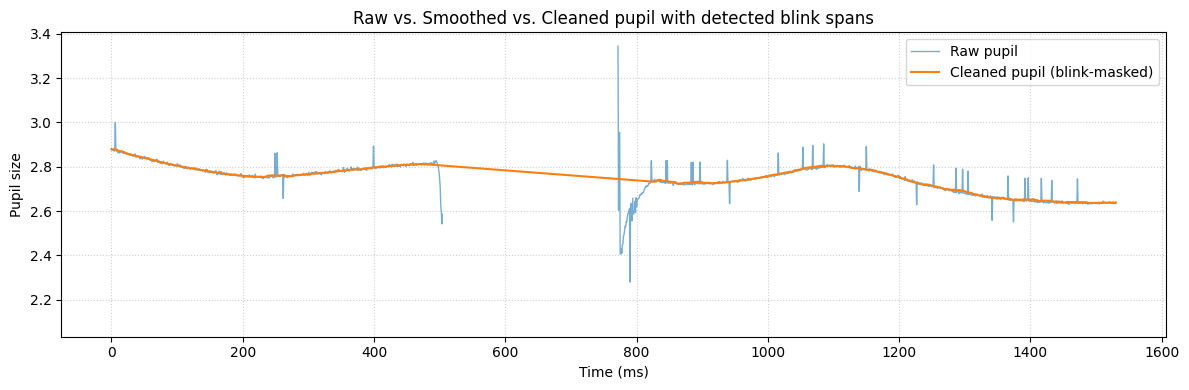

In [50]:
subjidx = 27
trial_idx = 360

fname1 = f'./data_raw/Experiment-2023_{subjid}_ET.csv'
fname2 = f'./data_raw/Experiment-2023_{subjid + 100}_ET.csv'
df1 = pd.read_csv(fname1)
df2 = pd.read_csv(fname2)

# renumber the trials and concatenate
df2['trial_number'] = df2['trial_number'] + df1['trial_number'].max()
df_eyedata = pd.concat([df1, df2], ignore_index=True)

# remove trial 0 (calibration measurement)
df_raw = df_eyedata[df_eyedata['trial_number'] > 0]
df_raw_trial = df_raw[df_raw['trial_number'] == trial_idx].copy()

# grab all samples
ts_start = df_raw_trial[df_raw_trial['trial_state'] == 'MEM']['system_time_stamp'].iloc[0]
ts_end = df_raw_trial[df_raw_trial['trial_state'] == 'RESP']['system_time_stamp'].iloc[0]


df_epoch = df_raw_trial[(df_raw_trial['system_time_stamp'] >= ts_start) & (df_raw_trial['system_time_stamp'] <= ts_end)].copy()

# set time relative to first sample
df_epoch['time'] = df_epoch['system_time_stamp'] - df_epoch['system_time_stamp'].min()

df_epoch['time'] = df_epoch['time'].apply(lambda x: int(x*1000))

# rename pupil columns to more convenient names
df_epoch = df_epoch.rename(columns = {'left_pupil_diameter':'left_pupil', 'right_pupil_diameter':'right_pupil'})

# Average left and right eye data points and then drop left/right data
df_epoch['avg_pupil'] = df_epoch[['left_pupil', 'right_pupil']].mean(axis=1)

def smooth_for_plot(x, sampling_freq, ms_4_smoothing=30):
    sampling_interval = 1000.0 / sampling_freq  # ms per sample
    # 样本窗口数（与你函数里一致的计算方式）
    samples2smooth = int(ms_4_smoothing // sampling_interval)
    # 保护：至少为 3 才会生效
    if samples2smooth < 3:
        return x.copy()
    # 调用你上面定义过的 smooth(x, window_len)
    return np.array(smooth(x, samples2smooth), dtype='float32')

# ========= 2) 生成可视化所需的序列 =========
def prepare_pupil_for_plot(pupil_size, sampling_freq):
    pupil_size = np.asarray(pupil_size, dtype=float)
    t_ms = np.arange(len(pupil_size)) * (1000.0 / sampling_freq)  # 时间轴(ms)
    ms_4_smoothing = 30
    samples2smooth = ms_4_smoothing // (1000.0 / sampling_freq) 
    pupil_smooth = np.array(smooth(pupil_size, samples2smooth), dtype='float32')
    # 把 0 也视为缺失的那行在你函数里是：
    # smooth_pupil_size[np.where(smooth_pupil_size == 0)[0]] = float('nan')
    # 只有在你的原始数据可能以 0 表示缺失时才建议这么做；否则可以注释掉
    pupil_smooth_zero_as_nan = pupil_smooth.copy()
    pupil_smooth_zero_as_nan[np.where(pupil_smooth_zero_as_nan == 0)[0]] = np.nan

    return t_ms, pupil_smooth_zero_as_nan

# ========= 3) 画图：原始、平滑、眨眼遮罩、清洗后 =========
def plot_pupil_with_blinks(pupil_size, sampling_freq):
    # 时间轴 + 平滑
    t_ms, pupil_smooth = prepare_pupil_for_plot(pupil_size, sampling_freq)

    # 调用你的检测函数，获得含 padding 的眨眼区间（单位 ms）
    blinks_df = based_noise_blinks_detection(pupil_size, sampling_freq)  # 你的函数

    # 构造“清洗后的 pupil”：把眨眼区间置为 NaN
    pupil_clean = np.array(pupil_smooth, dtype=float)
    blink_onsets = blinks_df["blink_onset"]  # onset
    blink_offsets = blinks_df["blink_offset"]  # offset
    # transform to DataFrame
    df = pd.DataFrame({
        'time': t_ms,
        'avg_pupil': pupil_clean 
    })

    # Interpolation
    for onset, offset in zip(blink_onsets, blink_offsets):
        df.loc[(df["time"] >= onset) & (df["time"] <= offset), ['avg_pupil']] = np.nan


    # linear interpolation
    df['avg_pupil'] = df['avg_pupil'] \
        .interpolate(method='linear') \
        .fillna(method='bfill') \
        .fillna(method='ffill')
    # === 绘图 ===
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    # 原始
    ax.plot(t_ms, pupil_size, label='Raw pupil', linewidth=1, alpha=0.6)
    # 处理
    ax.plot(t_ms, df['avg_pupil'].values, label='Cleaned pupil (blink-masked)', linewidth=1.5)


    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Pupil size')
    ax.set_title('Raw vs. Smoothed vs. Cleaned pupil with detected blink spans')
    ax.grid(True, linestyle='dotted', alpha=0.6)
    # 去重复图例条目
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    handles2, labels2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen and not l.startswith('_'):
            handles2.append(h); labels2.append(l); seen.add(l)
    ax.legend(handles2, labels2, loc='best')
    plt.tight_layout()
    plt.show()

    return blinks_df, pupil_smooth, pupil_clean

# ======= 使用示例 =======
pupil_size = df_epoch['avg_pupil']  # 你的 pupil 数组（包含 NaN 的原始轨迹）
sampling_freq = 1200.0  # 你的采样率 Hz
blinks_df, pupil_smooth, pupil_clean = plot_pupil_with_blinks(pupil_size, sampling_freq)


